In [1]:
#data_root = "/data/Data/latent_vectors/vqgan/ema_8x8x8_ctx_cosine_image_2/train"
data_root = "/data/Data/latent_vectors/vqgan/ema_8x8x8_ctx_cosine_box_cox/train"
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm 

In [2]:
#load all first .npz file and print the keys
files = os.listdir(data_root)
print(len(files))
files_0 = files[0]
data = np.load(os.path.join(data_root, files_0))
print(data.keys())
print(data["ctx"])
print(len(data["ctx"]))

6449
KeysView(NpzFile '/data/Data/latent_vectors/vqgan/ema_8x8x8_ctx_cosine_box_cox/train/CGPS-1_8341_SERIES0016_labels.nii.gz.npz' with keys: indices, ctx)
[[-0.47522148]
 [ 0.28791207]
 [ 0.49748635]
 [ 1.0625627 ]
 [-0.7007684 ]
 [ 1.0689331 ]
 [ 0.72908753]
 [ 0.504994  ]
 [ 1.034567  ]
 [ 0.9644095 ]
 [ 0.29209188]
 [ 0.5706744 ]
 [-1.004897  ]
 [ 0.12834714]
 [ 0.37436894]
 [ 0.7709304 ]
 [ 0.17806603]
 [ 1.2767255 ]]
18


In [3]:
#create a histogram of the condition vectors
data_mat = np.zeros((len(files), len(data["ctx"])))
for i, file in tqdm(enumerate(files)):
    data = np.load(os.path.join(data_root, file))
    data_mat[i, :] = data["ctx"].squeeze()

6449it [00:00, 19380.48it/s]


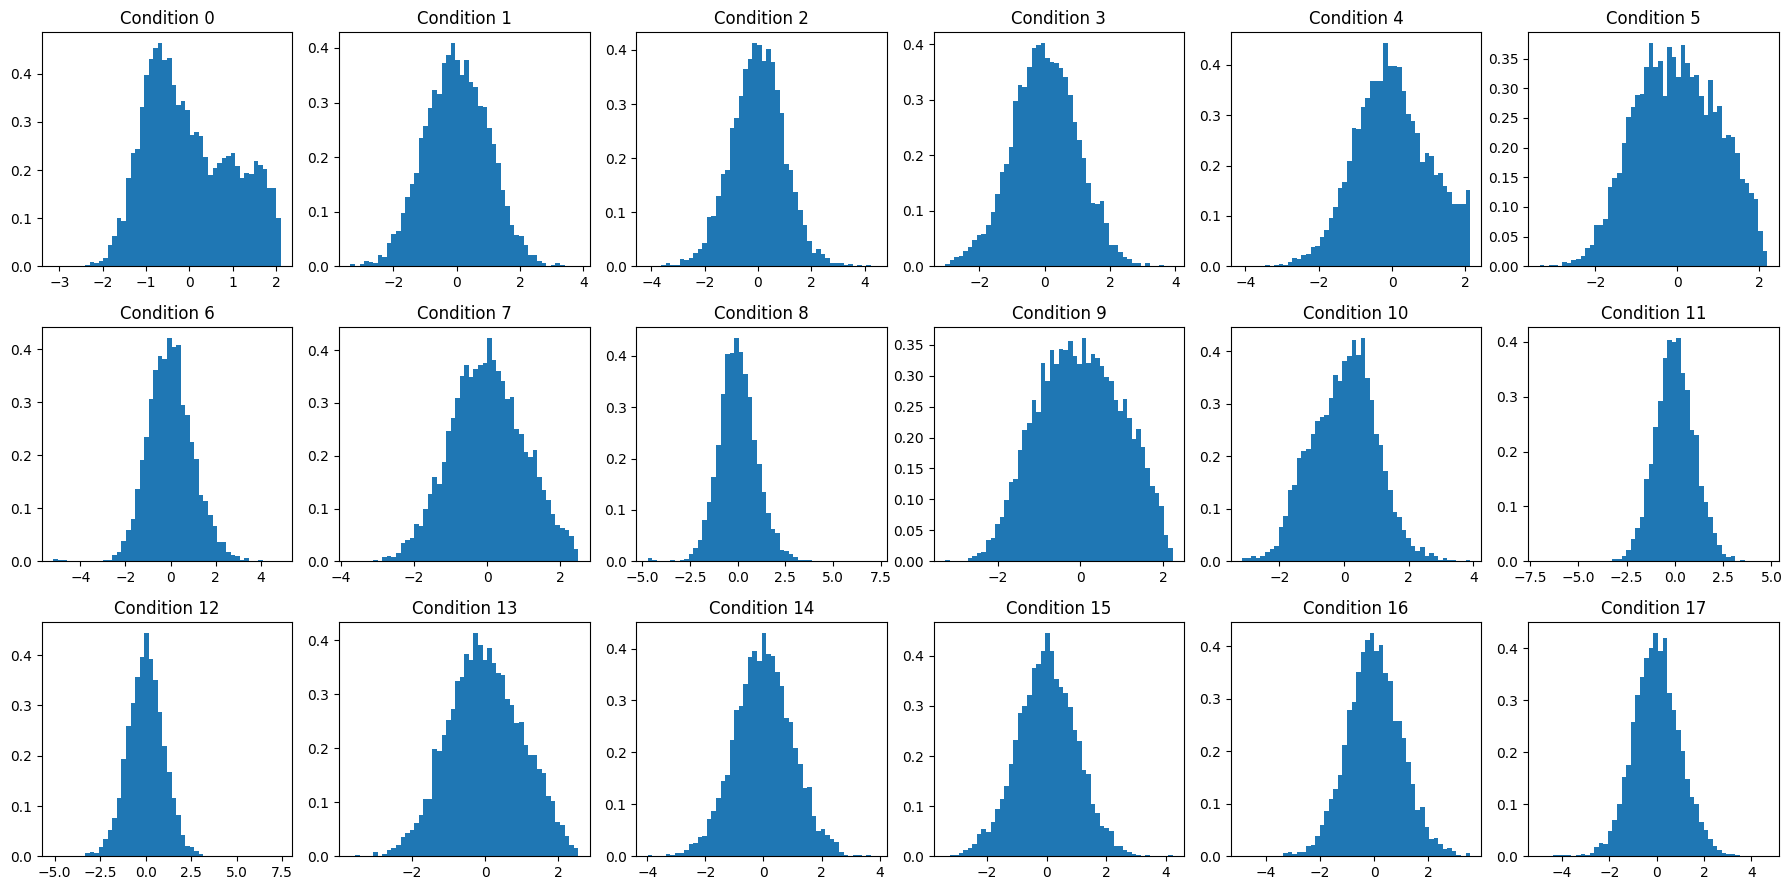

In [4]:
#plot the 18 condition distributions in a grid
fig, axs = plt.subplots(3, 6, figsize=(18, 9))
for i in range(18):
    ax = axs[i // 6, i % 6]
    ax.hist(data_mat[:, i], bins=50, density=True)
    ax.set_title(f"Condition {i}")
plt.tight_layout()
plt.show()

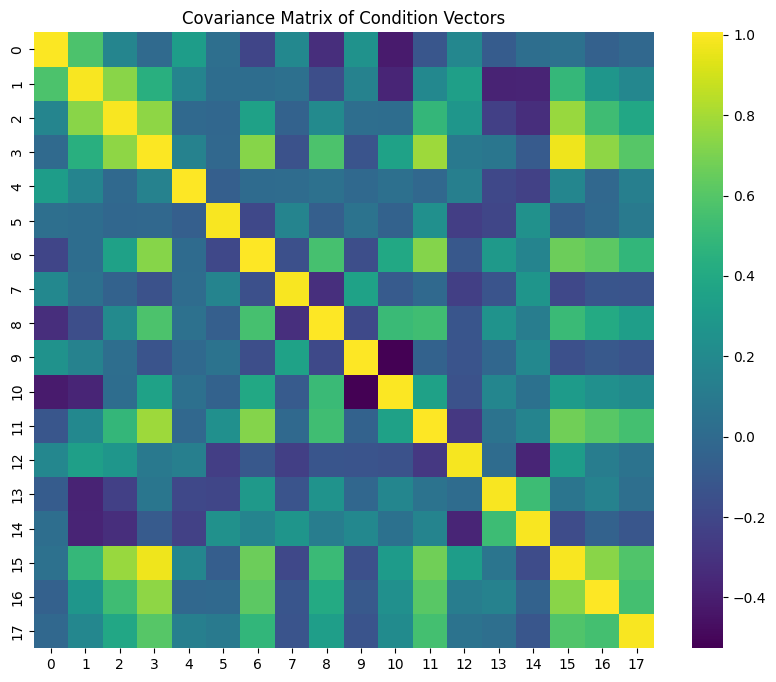

In [9]:
#make covariance matrix of data_mat and display it using sns
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(np.cov(data_mat, rowvar=False), cmap='viridis')
plt.title("Covariance Matrix of Condition Vectors")
plt.show()

In [ ]:
#save the covariance matrix to /data/Data/laa_measures/cond_distr_normal.npz"
import pandas as pd
cov_mat = np.cov(data_mat, rowvar=False)
norm_params_df = pd.DataFrame(cov_mat)
norm_params_df.to_csv("/storage/code/VQ_diffusion/help_folder/statistics/covariance_matrix.csv", index=False)

In [13]:
import pandas as pd
mean_vec = np.mean(data_mat, axis=0)
mean_vec_df = pd.DataFrame(mean_vec)
mean_vec_df.to_csv("/storage/code/VQ_diffusion/help_folder/statistics/mean_vector.csv", index=False)

In [5]:
import pandas as pd 
import numpy as np
import json
from tqdm import tqdm
import os 

DATA_DIR = "/data/Data/LAAAnalysis-October-2025/LabelMaps"

def csv2list(csv_path, exclude_list):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_path)
    laa_measures_list = []
    no_label_list = []
    for idx, row in df.iterrows():
        row_dict = row.to_dict()
        if row_dict["scan_name"] in exclude_list:
            continue
        #check if the file actually exists
        if not os.path.exists(os.path.join(DATA_DIR, row_dict["scan_name"]+"_labels.nii.gz")):
            no_label_list.append(row_dict["scan_name"])
            continue
        else: 
            #delete the 'Unnamed: 46' key
            del row_dict['dims_x']
            del row_dict['dims_y']
            del row_dict['dims_z']
            new_name = row_dict["scan_name"]+".nii.gz"
            #insert new_name into the row_dict
            row_dict["filename"] = new_name
            #delete the old name
            del row_dict["scan_name"]
            del row_dict['pseudo_id']
            laa_measures_list.append(row_dict)
        # Convert the DataFrame to a list of dictionaries
    print("No label files for the following scans:", no_label_list)
    return laa_measures_list

def quantile_normalize_list(laa_measures_csv, exclude_list, output_path, q_low=0.010, q_high=0.990):
    # Convert laa_measuress of dictionaries to DataFrames
    #laa_measures is a csv file 
    laa_measures_list = csv2list(laa_measures_csv, exclude_list)
    df = pd.DataFrame(laa_measures_list)
    
    # Identify numeric columns. (We assume both laa_measuress have the same keys.)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Make copies for the normalized versions
    df_norm = df.copy()
    #if any value in a row is nan, drop the row
    df_norm = df_norm.dropna()

    norm_params = []

    # For each numeric column, compute the union quantiles and normalize
    for col in tqdm(numeric_cols):
        if col == "estimated_bifurcations":
            # Skip normalization for this column; leave as-is.
            continue
        # Combine the column values from both dataframes

        lower = df[col].quantile(q_low)
        upper = df[col].quantile(q_high)
        
        # Avoid division by zero in case upper equals lower
        if upper == lower:
            df_norm[col] = 0.0
        else:
            # Apply min–max normalization and clip the results to [0, 1]
            df_norm[col] = ((df[col] - lower) / (upper - lower)).clip(0.0, 1.0)

        # create a dataframe with lower and upper for each column
        norm_params.append({'feature': col, 'lower_quantile': lower, 'upper_quantile': upper})
    
    # Convert back to laa_measures of dictionaries
    norm_laa_measures = df_norm.to_dict(orient='records')

    # with open(output_path, 'w') as outfile:
    #     json.dump(norm_laa_measures, outfile, indent=4)
    norm_params = pd.DataFrame(norm_params)
    return norm_params

def std_mean_normalization(laa_measures_csv, exclude_list, output_path):
    # Convert laa_measuress of dictionaries to DataFrames
    laa_measures_list = csv2list(laa_measures_csv, exclude_list)
    df = pd.DataFrame(laa_measures_list)
    
    # Identify numeric columns. (We assume both laa_measuress have the same keys.)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Make copies for the normalized versions
    df_norm = df.copy()
    df_norm = df_norm.dropna()
    
    # For each numeric column, compute the mean and std and normalize
    for col in tqdm(numeric_cols):
        if col == "estimated_bifurcations":
            # Skip normalization for this column; leave as-is.
            continue
        mean = df[col].mean()
        std = df[col].std()
        
        # Avoid division by zero in case std equals zero
        if std == 0:
            df_norm[col] = 0.0
        else:
            # Apply z-score normalization
            df_norm[col] = (df[col] - mean) / std
    
    # Convert back to laa_measures of dictionaries
    norm_laa_measures = df_norm.to_dict(orient='records')

    # with open(output_path, 'w') as outfile:
    #     json.dump(norm_laa_measures, outfile, indent=4)

In [6]:
exclude_txt = "/storage/code/quality_control/bad_filenames_2.txt"
#load the exlude_txt into a list
with open(exclude_txt, 'r') as f:
    exclude_list = f.read().splitlines()
#remove "_labels" from each element in the list
exclude_list = [x.replace("_labels", "") for x in exclude_list]

input_path = "/data/Data/LAAAnalysis-October-2025/DTULAAMeasures-30-10-2025/laa_measures-statistics-fixed.csv"
output_path_quantile = "/data/Data/laa_measures/quantile_normalized.json"
output_path_std = "/data/Data/laa_measures/std_mean_normalized.json"
norm_params = quantile_normalize_list(input_path, exclude_list, output_path_quantile)
#std_mean_normalization(input_path, exclude_list, output_path_std)


No label files for the following scans: ['CGPS-1_0002_SERIES0017']


100%|██████████| 42/42 [00:00<00:00, 1098.48it/s]


In [12]:
norm_params

,feature,lower_quantile,upper_quantile
0,max_euclidean_distance_to_ostium,23.523310,47.126642
1,geodesic_distance_at_furthest_point,31.466150,60.458572
2,furtherst_point_geodesic_ratio,1.160291,1.565271
3,max_geodesic_distance,34.130505,63.232048
4,centerline_length,24.094605,63.944719
5,euclidean_distance,19.309855,45.731002
6,tortuosity,1.077935,2.237237
7,radii_mean,2.194542,5.982649
8,radii_std,0.750962,2.420825
9,radii_median,1.569416,6.377753


In [7]:
laa_measures_list = csv2list(input_path, exclude_list)
df = pd.DataFrame(laa_measures_list).dropna()
df.head()

No label files for the following scans: ['CGPS-1_0002_SERIES0017']


,max_euclidean_distance_to_ostium,geodesic_distance_at_furthest_point,furtherst_point_geodesic_ratio,estimated_bifurcations,max_geodesic_distance,centerline_length,euclidean_distance,tortuosity,radii_mean,radii_std,...,ostium_least_axis_length,ostium_elongation,ostium_flatness,major_axis_length,minor_axis_length,least_axis_length,elongation,flatness,angle_ostium_laa,filename
0,27.643539,34.196287,1.237044,3,37.445325,25.744924,21.676619,1.187682,4.535677,1.645548,...,1.640202,0.729143,0.072242,37.624792,25.272486,20.373521,0.671698,0.541492,81.604775,CGPS-1_0000_SERIES0014.nii.gz
1,24.889825,43.417303,1.744380,1,43.788883,39.819095,24.870263,1.601073,4.056285,1.124362,...,1.787596,0.906388,0.097517,35.035943,26.617694,15.186327,0.759725,0.433450,89.531068,CGPS-1_0001_SERIES0005.nii.gz
2,31.863185,43.060847,1.351429,2,43.701785,34.583876,30.128846,1.147866,4.727641,1.518502,...,3.370486,0.610015,0.105752,39.880312,32.753758,20.436549,0.821301,0.512447,52.430596,CGPS-1_0003_SERIES0001.nii.gz
3,33.338466,43.320701,1.299421,2,47.839881,45.923002,28.878115,1.590235,2.559094,2.054925,...,1.717285,0.587760,0.061031,42.546363,34.436251,19.892301,0.809382,0.467544,70.113353,CGPS-1_0007_SERIES0007.nii.gz
4,32.163692,43.206577,1.343334,2,43.979953,39.736884,31.492457,1.261791,3.235549,1.954771,...,1.855640,0.949060,0.083438,39.344114,28.229214,16.386920,0.717495,0.416502,59.413304,CGPS-1_0008_SERIES0006.nii.gz


In [8]:
keys = ["tortuosity", "centerline_length", "max_geodesic_distance", "volume",
        "angle_ostium_laa", "cl_cut_25_elongation", "cl_cut_25_cutarea", "cl_cut_50_elongation", "cl_cut_50_cutarea",
        "cl_cut_75_elongation", "cl_cut_75_cutarea", "radii_95", "normalized_shape_index",
        "elongation", "flatness", "surface_area", "ostium_major_axis_length", "ostium_minor_axis_length"]

#remove all columns except the keys above and filename
df = df[["filename"] + keys]
df.head()

,filename,tortuosity,centerline_length,max_geodesic_distance,volume,angle_ostium_laa,cl_cut_25_elongation,cl_cut_25_cutarea,cl_cut_50_elongation,cl_cut_50_cutarea,cl_cut_75_elongation,cl_cut_75_cutarea,radii_95,normalized_shape_index,elongation,flatness,surface_area,ostium_major_axis_length,ostium_minor_axis_length
0,CGPS-1_0000_SERIES0014.nii.gz,1.187682,25.744924,37.445325,5443.347570,81.604775,0.566548,448.980459,0.778910,222.982467,0.616944,200.708737,6.233047,1.257797,0.671698,0.541492,2367.460514,22.704187,16.554589
1,CGPS-1_0001_SERIES0005.nii.gz,1.601073,39.819095,43.788883,3966.345484,89.531068,0.668848,108.621613,0.904476,83.586955,0.535617,108.854984,5.249879,1.251527,0.759725,0.433450,1897.980231,18.331110,16.615096
2,CGPS-1_0003_SERIES0001.nii.gz,1.147866,34.583876,43.701785,7371.331252,52.430596,0.782125,308.849343,0.512563,223.217485,0.498955,124.858467,7.162777,1.278468,0.821301,0.512447,2993.832787,31.871551,19.442110
3,CGPS-1_0007_SERIES0007.nii.gz,1.590235,45.923002,47.839881,8655.555108,70.113353,0.437170,470.423664,0.389878,252.910798,0.692698,18.845737,7.027009,1.285107,0.809382,0.467544,3366.868605,28.137850,16.538310
4,CGPS-1_0008_SERIES0006.nii.gz,1.261791,39.736884,43.979953,5535.011460,59.413304,0.649029,285.924362,0.629820,121.287881,0.351512,67.693772,6.395256,1.252479,0.717495,0.416502,2373.762808,22.239741,21.106844


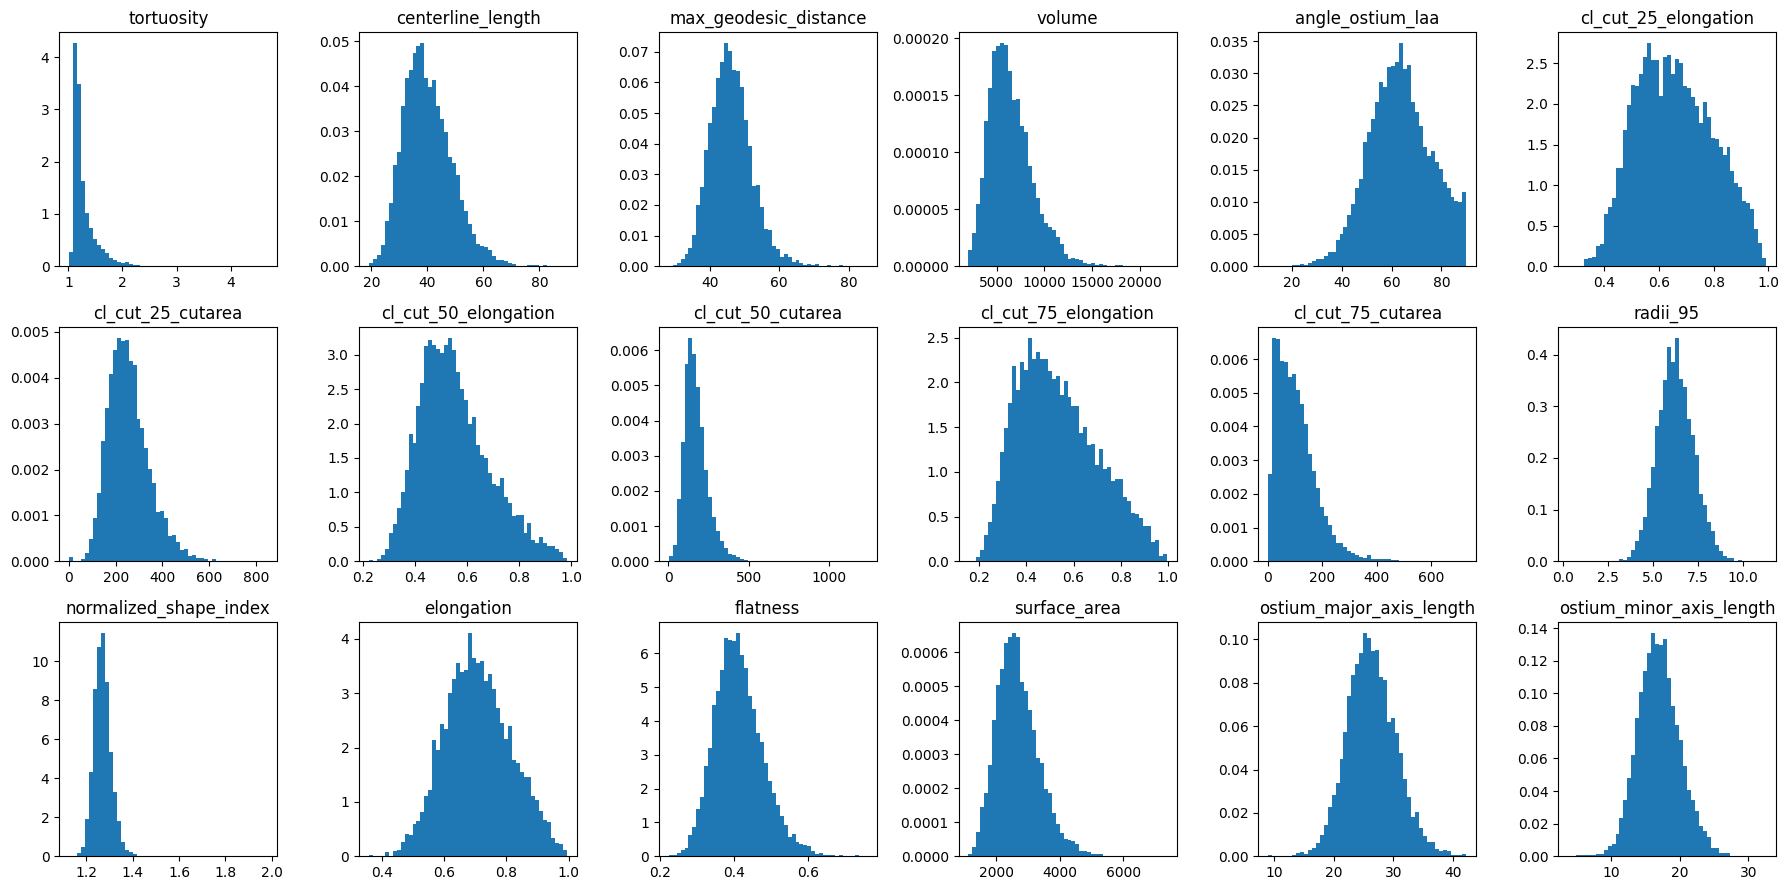

In [9]:
#plot the histograms of each key in a grid for df with 3 rows and 6 columns
fig, axs = plt.subplots(3, 6, figsize=(18, 9))
for i, key in enumerate(keys):
    ax = axs[i // 6, i % 6]
    ax.hist(df[key], bins=50, density=True)
    ax.set_title(f"{key}")
plt.tight_layout()
plt.show()

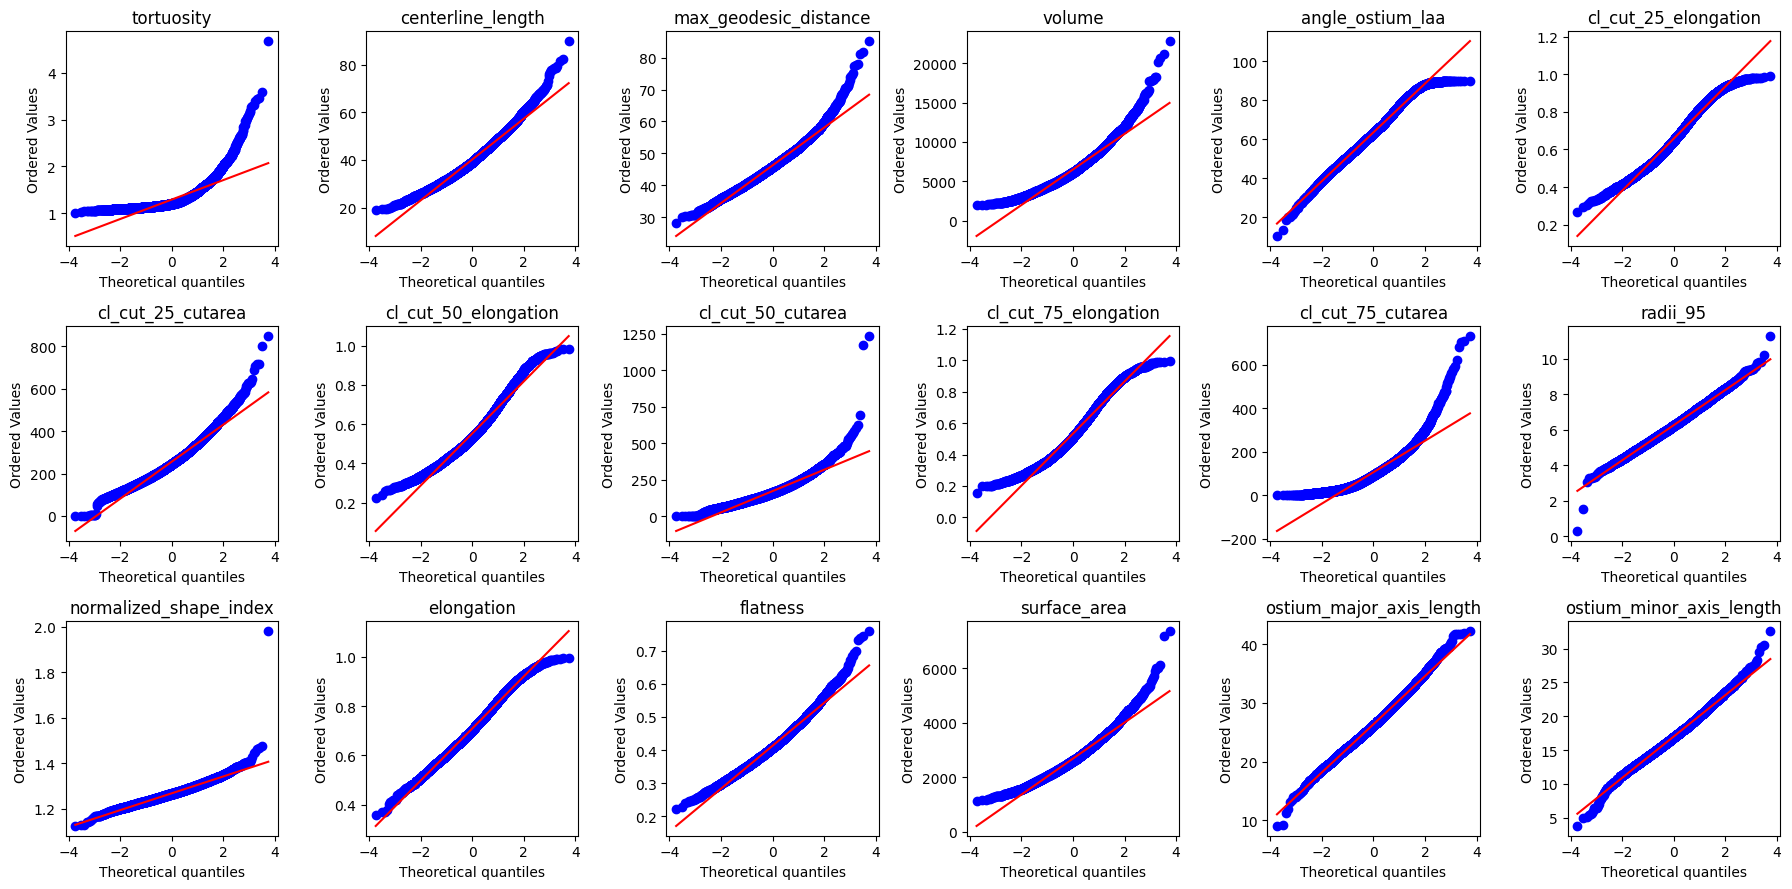

In [10]:
#QQ plot for each key in keys
import scipy.stats as stats
fig, axs = plt.subplots(3, 6, figsize=(18, 9))
for i, key in enumerate(keys):
    ax = axs[i // 6, i % 6]
    stats.probplot(df[key], dist="norm", plot=ax)
    ax.set_title(f"{key}")
plt.tight_layout()
plt.show()

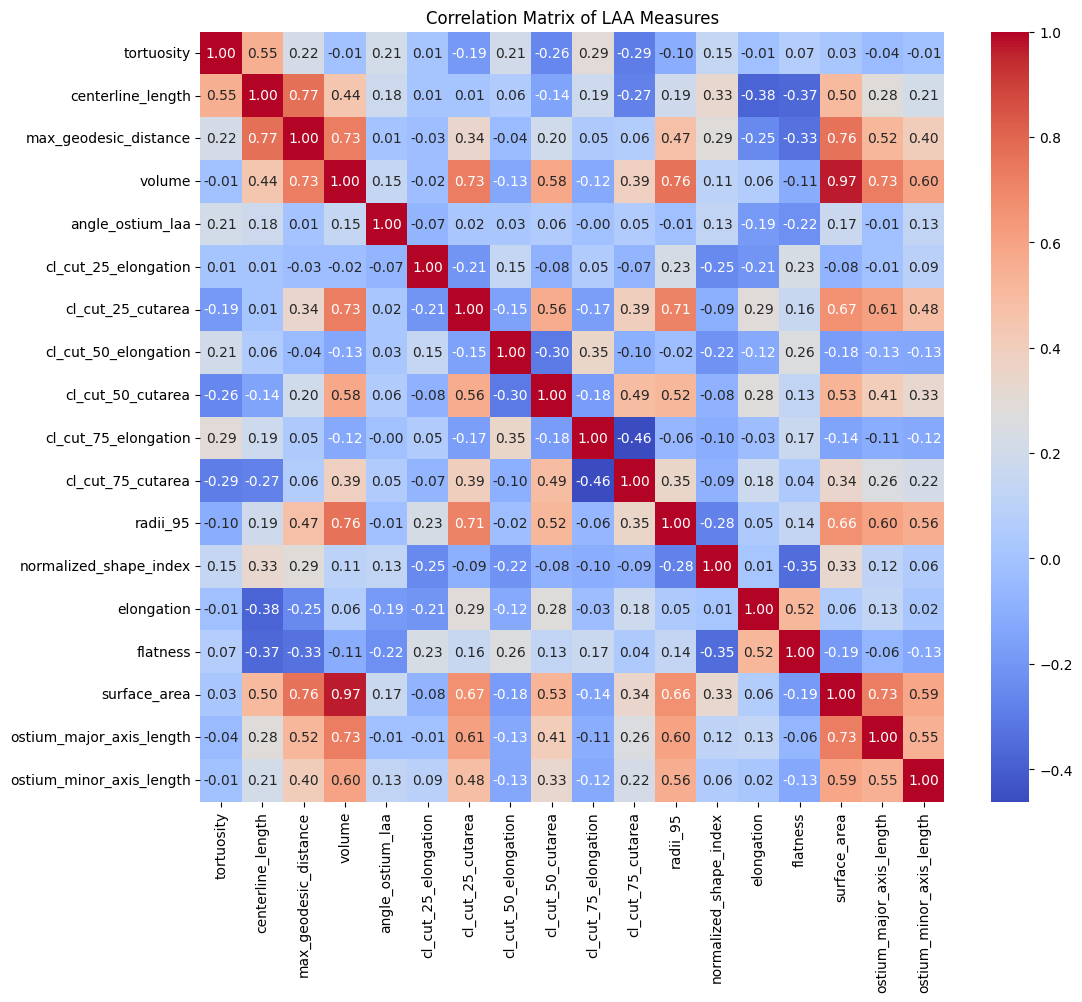

In [28]:
#correlation matrix heatmap for the keys in df
import seaborn as sns
corr = df[keys].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of LAA Measures")
plt.show()

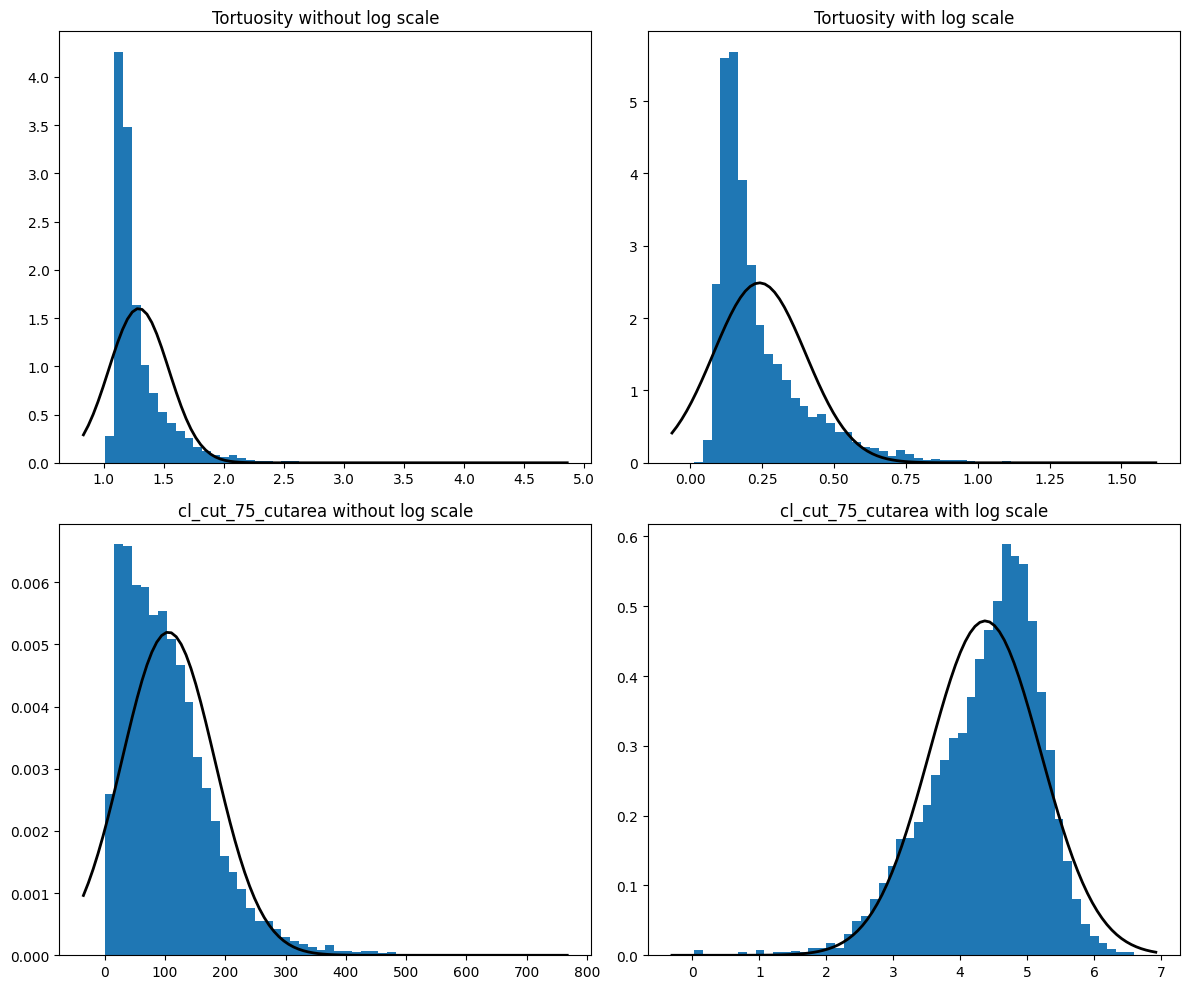

In [17]:
#plot the histogram of turtuosity and cl_cut_75_cutarea with and without log scale in 2x2 plot. Also fit a normal distribution curve to each histogram
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
import scipy.stats as stats
#tortuosity without log scale
ax = axs[0, 0]
ax.hist(df["tortuosity"], bins=50, density=True)
mu, std = stats.norm.fit(df["tortuosity"])
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("Tortuosity without log scale")
#tortuosity with log scale
ax = axs[0, 1]
ax.hist(np.log(df["tortuosity"]+1e-10), bins=50, density=True)
mu, std = stats.norm.fit(np.log(df["tortuosity"]+1e-10))
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("Tortuosity with log scale")
#cl_cut_75_cutarea without log scale
ax = axs[1, 0]
ax.hist(df["cl_cut_75_cutarea"], bins=50, density=True)
mu, std = stats.norm.fit(df["cl_cut_75_cutarea"])
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("cl_cut_75_cutarea without log scale")
#cl_cut_75_cutarea with log scale
ax = axs[1, 1]
ax.hist(np.log(df["cl_cut_75_cutarea"]+1e-10), bins=50, density=True)
mu, std = stats.norm.fit(np.log(df["cl_cut_75_cutarea"]+1e-10))
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("cl_cut_75_cutarea with log scale")
plt.tight_layout()
plt.show()

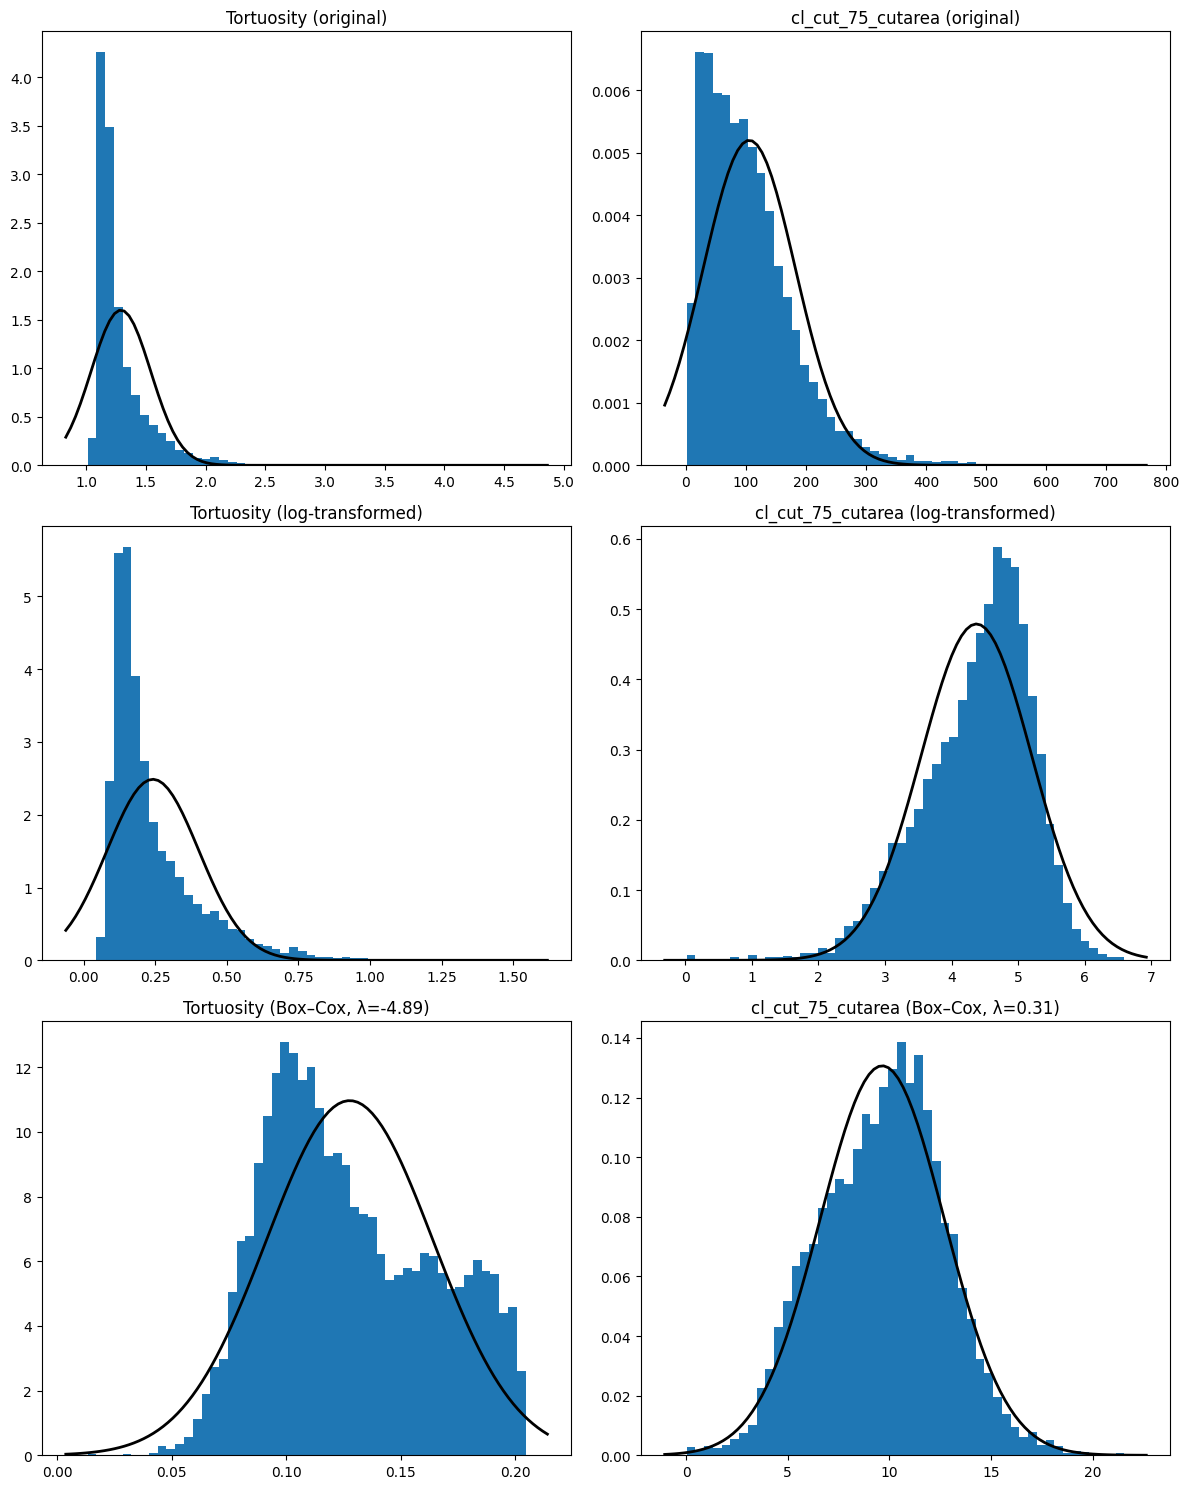

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axs = plt.subplots(3, 2, figsize=(12, 15))

# --- 1st row: original tortuosity and cl_cut_75_cutarea ---

# Tortuosity without log scale
ax = axs[0, 0]
ax.hist(df["tortuosity"], bins=50, density=True)
mu, std = stats.norm.fit(df["tortuosity"])
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("Tortuosity (original)")

# cl_cut_75_cutarea without log scale
ax = axs[0, 1]
ax.hist(df["cl_cut_75_cutarea"], bins=50, density=True)
mu, std = stats.norm.fit(df["cl_cut_75_cutarea"])
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("cl_cut_75_cutarea (original)")

# --- 2nd row: log-transformed versions ---

# Tortuosity with log scale
tort_log = np.log(df["tortuosity"] + 1e-10)
ax = axs[1, 0]
ax.hist(tort_log, bins=50, density=True)
mu, std = stats.norm.fit(tort_log)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("Tortuosity (log-transformed)")

# cl_cut_75_cutarea with log scale
cl_log = np.log(df["cl_cut_75_cutarea"] + 1e-10)
ax = axs[1, 1]
ax.hist(cl_log, bins=50, density=True)
mu, std = stats.norm.fit(cl_log)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title("cl_cut_75_cutarea (log-transformed)")

# --- 3rd row: Box–Cox transformed versions ---

# Tortuosity Box–Cox
# Box–Cox needs strictly positive data; +1e-10 is just a tiny shift
tort_pos = df["tortuosity"] + 1e-10
tort_boxcox, tort_lambda = stats.boxcox(tort_pos)

ax = axs[2, 0]
ax.hist(tort_boxcox, bins=50, density=True)
mu, std = stats.norm.fit(tort_boxcox)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title(f"Tortuosity (Box–Cox, λ={tort_lambda:.2f})")

# cl_cut_75_cutarea Box–Cox
cl_pos = df["cl_cut_75_cutarea"] + 1e-10
cl_boxcox, cl_lambda = stats.boxcox(cl_pos)

ax = axs[2, 1]
ax.hist(cl_boxcox, bins=50, density=True)
mu, std = stats.norm.fit(cl_boxcox)
xmin, xmax = ax.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax.plot(x, p, 'k', linewidth=2)
ax.set_title(f"cl_cut_75_cutarea (Box–Cox, λ={cl_lambda:.2f})")

plt.tight_layout()
plt.show()


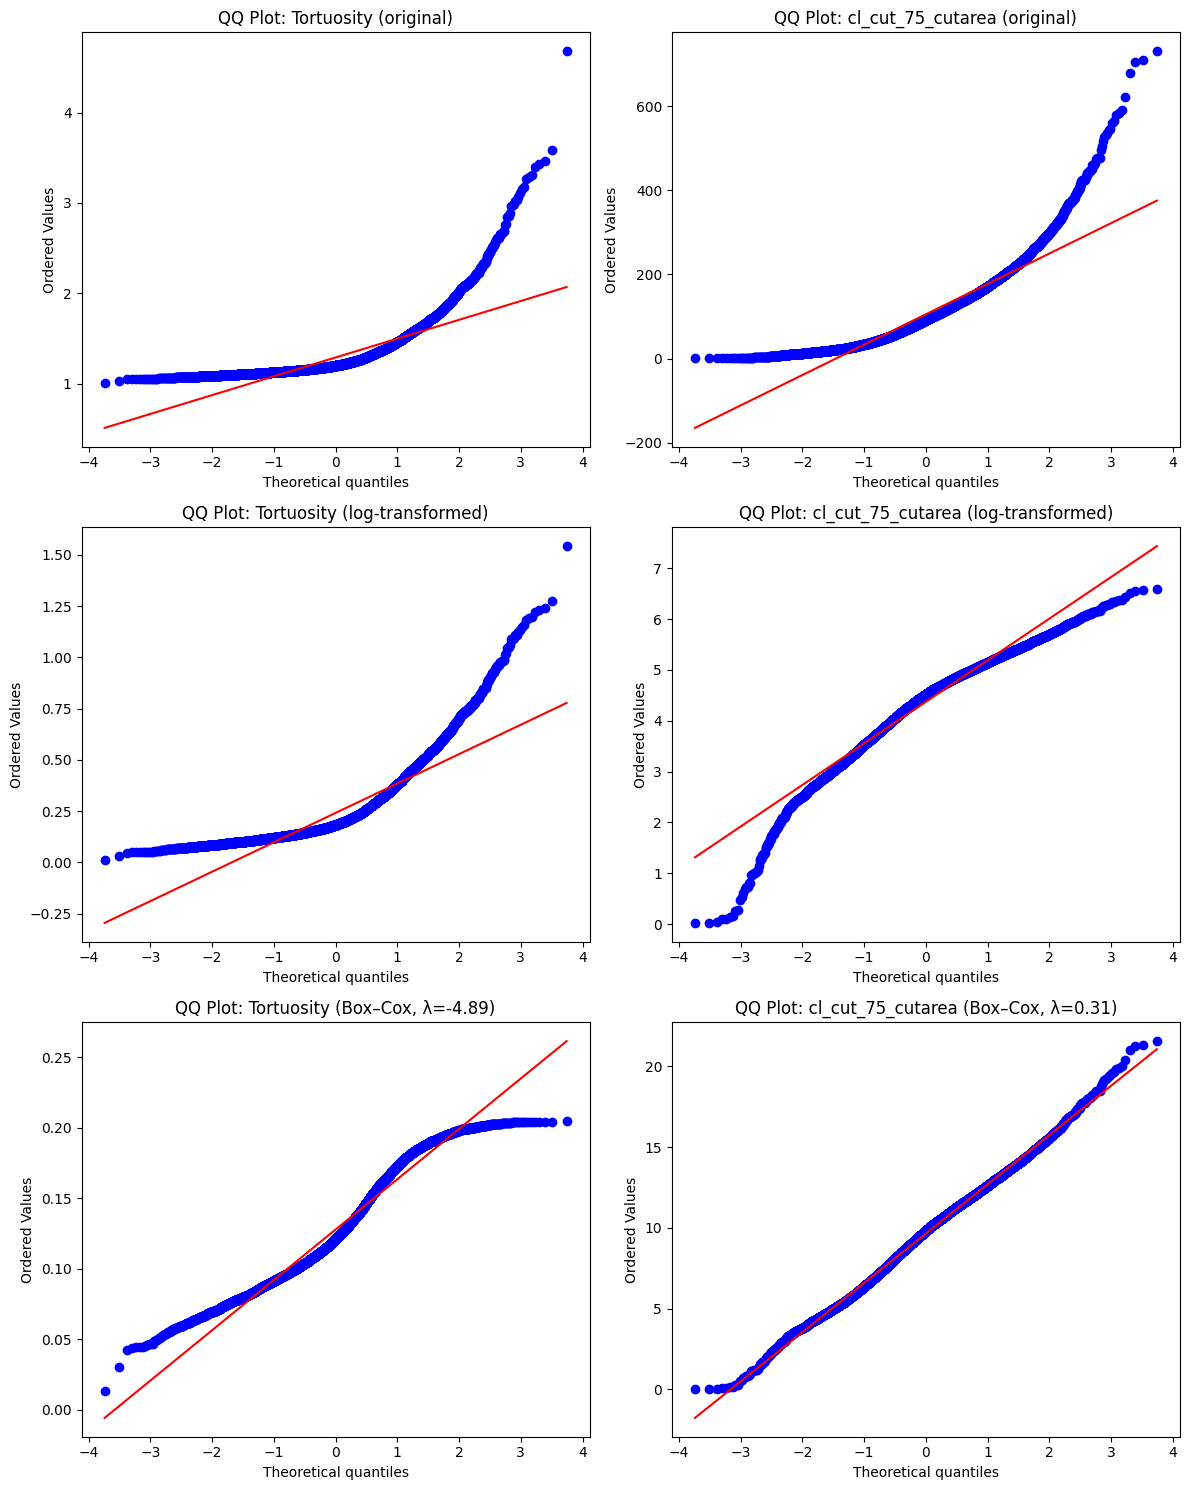

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 3x2 QQ-plot grid
fig, axs = plt.subplots(3, 2, figsize=(12, 15))

# --- 1st row: original ---

# Tortuosity (original)
ax = axs[0, 0]
stats.probplot(df["tortuosity"], dist="norm", plot=ax)
ax.set_title("QQ Plot: Tortuosity (original)")

# cl_cut_75_cutarea (original)
ax = axs[0, 1]
stats.probplot(df["cl_cut_75_cutarea"], dist="norm", plot=ax)
ax.set_title("QQ Plot: cl_cut_75_cutarea (original)")

# --- 2nd row: log-transformed ---

# Tortuosity (log)
tort_log = np.log(df["tortuosity"] + 1e-10)
ax = axs[1, 0]
stats.probplot(tort_log, dist="norm", plot=ax)
ax.set_title("QQ Plot: Tortuosity (log-transformed)")

# cl_cut_75_cutarea (log)
cl_log = np.log(df["cl_cut_75_cutarea"] + 1e-10)
ax = axs[1, 1]
stats.probplot(cl_log, dist="norm", plot=ax)
ax.set_title("QQ Plot: cl_cut_75_cutarea (log-transformed)")

# --- 3rd row: Box–Cox transformed ---

# Tortuosity (Box–Cox) – requires strictly positive data
tort_pos = df["tortuosity"] + 1e-10
tort_boxcox, tort_lambda = stats.boxcox(tort_pos)

ax = axs[2, 0]
stats.probplot(tort_boxcox, dist="norm", plot=ax)
ax.set_title(f"QQ Plot: Tortuosity (Box–Cox, λ={tort_lambda:.2f})")

# cl_cut_75_cutarea (Box–Cox)
cl_pos = df["cl_cut_75_cutarea"] + 1e-10
cl_boxcox, cl_lambda = stats.boxcox(cl_pos)

ax = axs[2, 1]
stats.probplot(cl_boxcox, dist="norm", plot=ax)
ax.set_title(f"QQ Plot: cl_cut_75_cutarea (Box–Cox, λ={cl_lambda:.2f})")

plt.tight_layout()
plt.show()


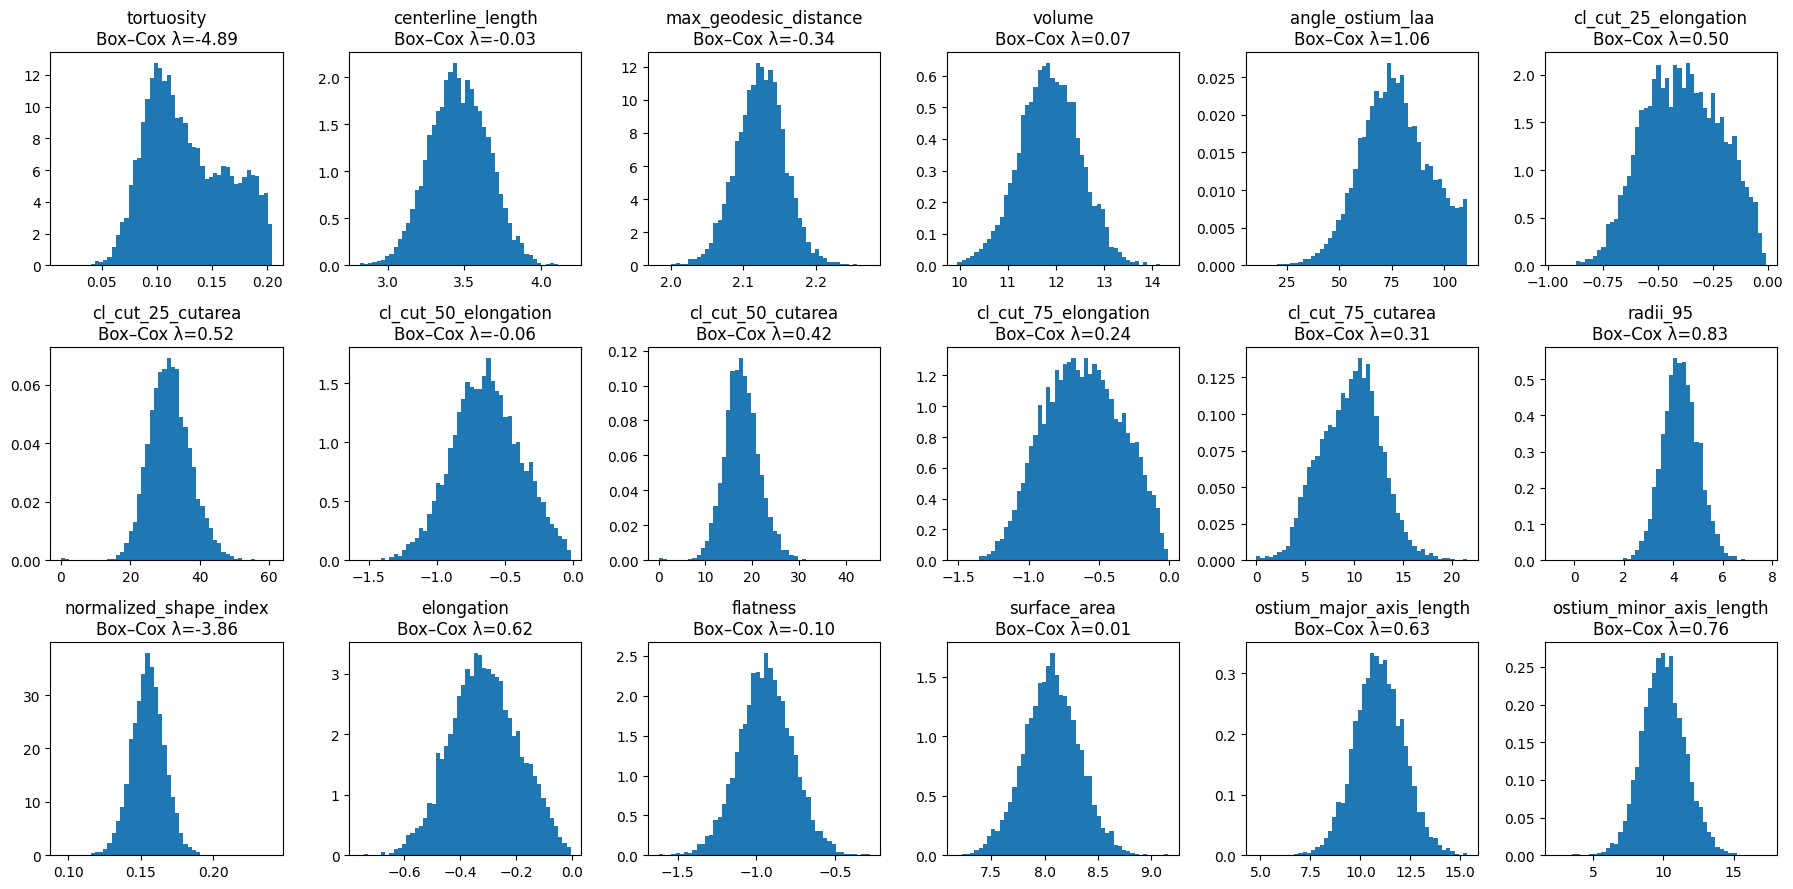

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(3, 6, figsize=(18, 9))

for i, key in enumerate(keys):
    ax = axs[i // 6, i % 6]
    
    # Take the column and drop NaNs
    data = df[key].dropna().values
    
    # Box–Cox needs strictly positive data ⇒ shift if necessary
    shift = 0.0
    min_val = data.min()
    if min_val <= 0:
        shift = -min_val + 1e-8  # small epsilon to ensure strictly > 0
    
    data_pos = data + shift
    
    # Apply Box–Cox
    data_bc, lam = stats.boxcox(data_pos)
    
    # Plot histogram of Box–Cox–transformed data
    ax.hist(data_bc, bins=50, density=True)
    if shift != 0.0:
        ax.set_title(f"{key}\nBox–Cox λ={lam:.2f}, shift={shift:.2g}")
    else:
        ax.set_title(f"{key}\nBox–Cox λ={lam:.2f}")

plt.tight_layout()
plt.show()


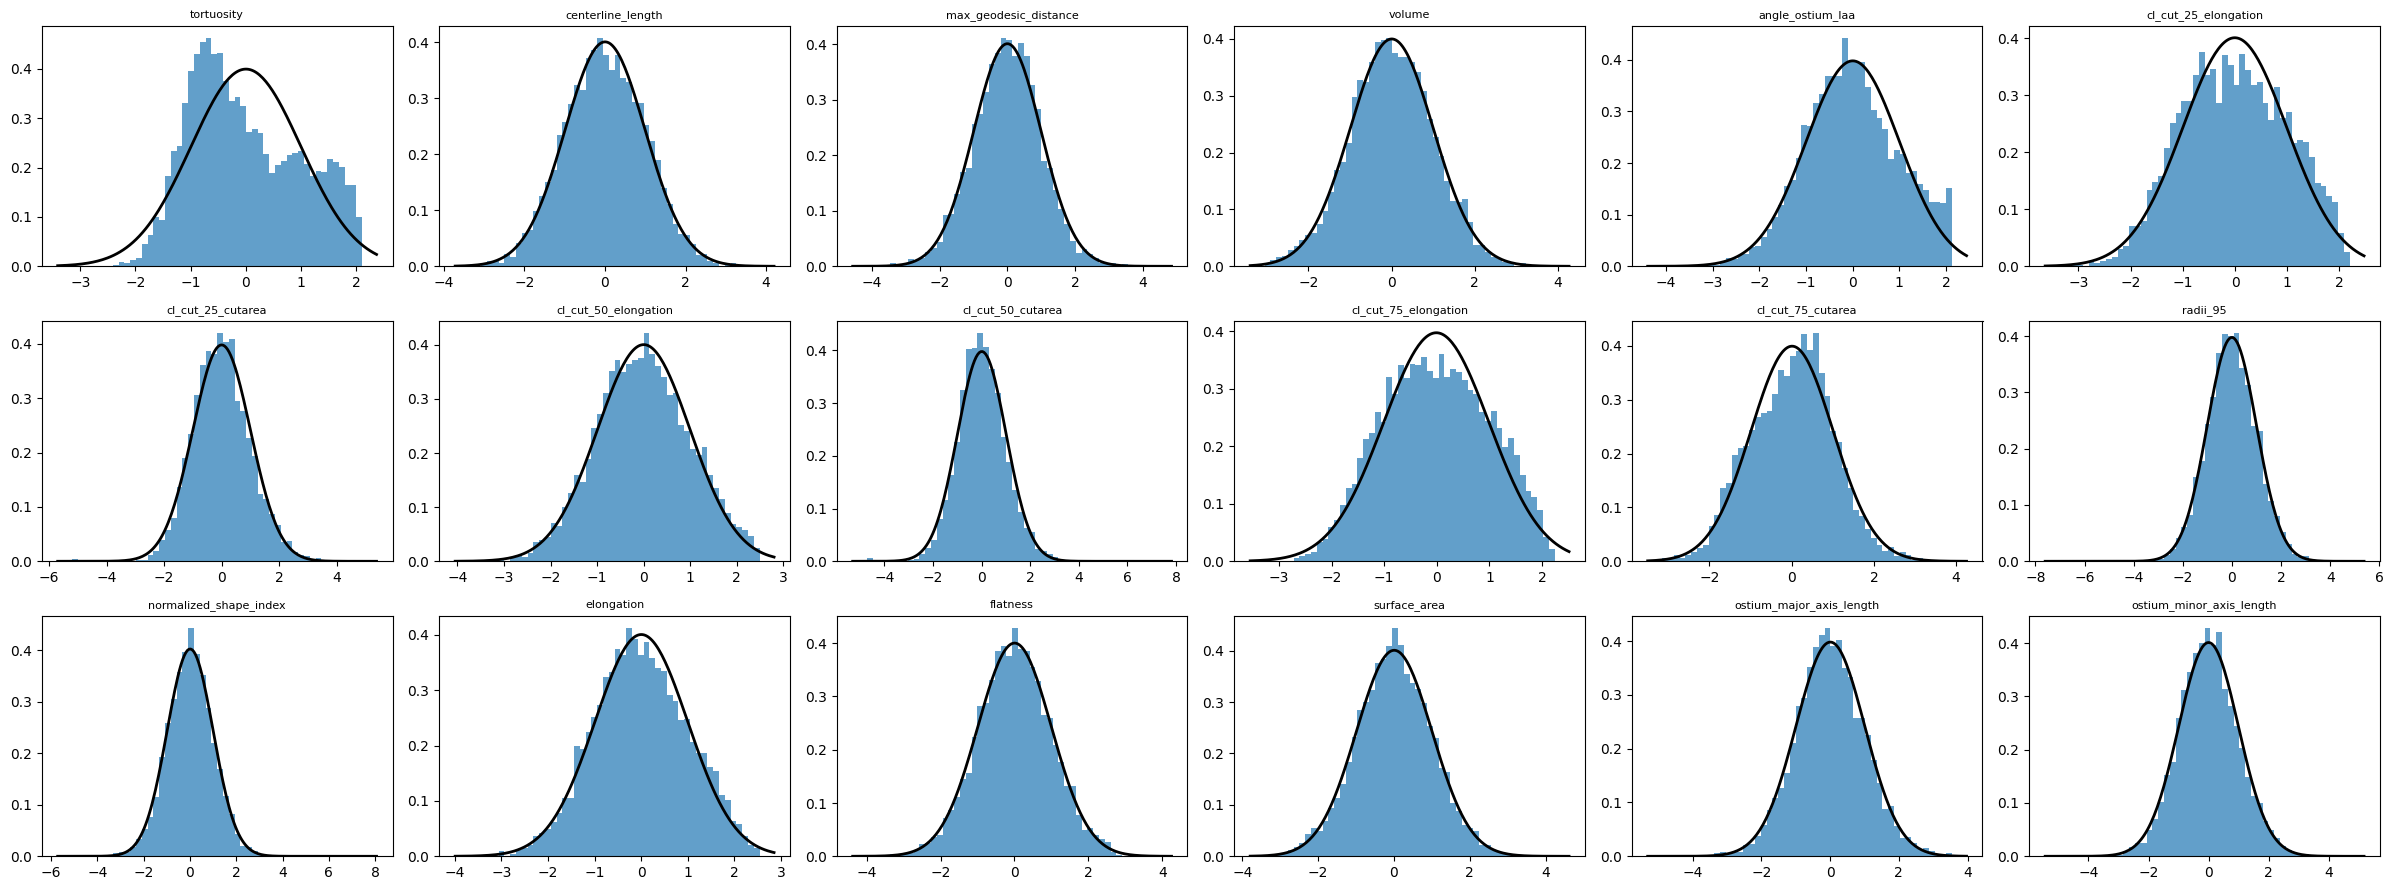

In [24]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load the JSON file
json_path = "/data/Data/laa_measures/train_normalized_boxcox/normalized_boxcox.json"  # update path if needed
keys = ["tortuosity", "centerline_length", "max_geodesic_distance", "volume",
        "angle_ostium_laa", "cl_cut_25_elongation", "cl_cut_25_cutarea", "cl_cut_50_elongation", "cl_cut_50_cutarea",
        "cl_cut_75_elongation", "cl_cut_75_cutarea", "radii_95", "normalized_shape_index",
        "elongation", "flatness", "surface_area", "ostium_major_axis_length", "ostium_minor_axis_length"]

with open(json_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Select columns (exclude non-features like filename)
selected_cols = [col for col in keys if col in df.columns]

# If you want to explicitly drop discrete counters like 'estimated_bifurcations', do:
# numeric_cols = [c for c in numeric_cols if c != "estimated_bifurcations"]

# 3 x 6 subplot (18 features max)
rows, cols = 3, 6
fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axs = axs.ravel()

for i, col in enumerate(selected_cols[:rows * cols]):
    ax = axs[i]
    vals = df[col].dropna().values
    if vals.size == 0:
        ax.set_title(f"{col}\n(no data)")
        continue

    # Histogram
    ax.hist(vals, bins=50, density=True, alpha=0.7)

    # Fit normal distribution and overlay
    mu, std = stats.norm.fit(vals)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 200)
    pdf = stats.norm.pdf(x, mu, std)
    ax.plot(x, pdf, "k", linewidth=2)

    ax.set_title(col, fontsize=8)

# Hide any unused axes if there are fewer than 18 numeric columns
for j in range(len(selected_cols), rows * cols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

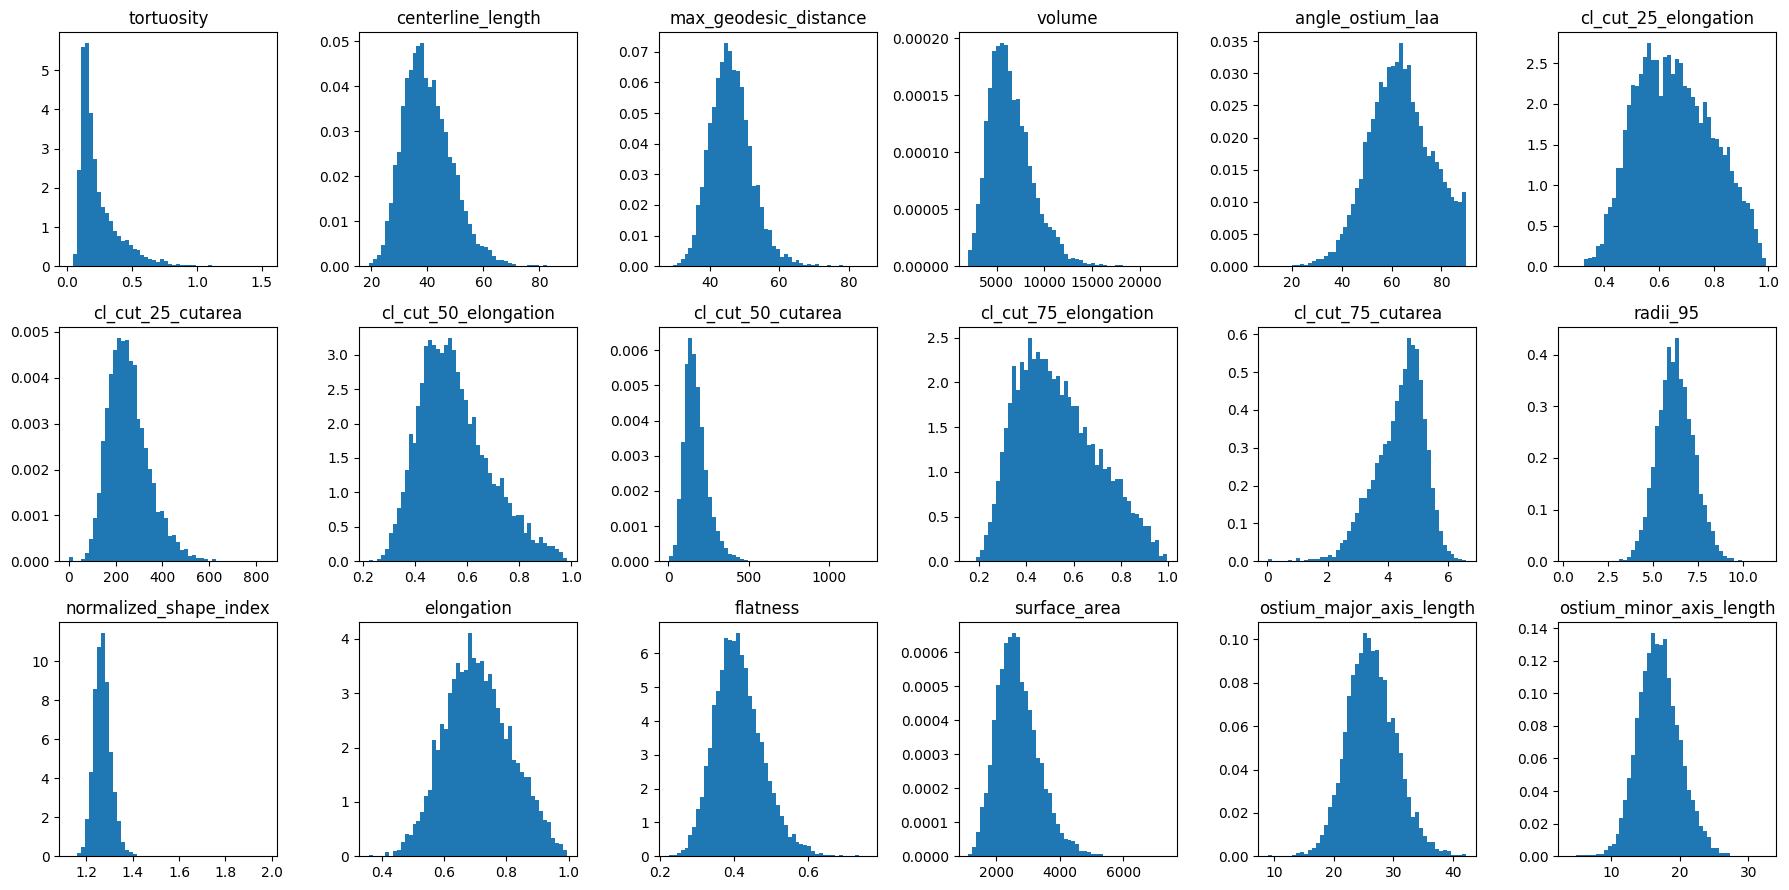

In [13]:
#plot the histograms of each key in a grid for df with 3 rows and 6 columns
fig, axs = plt.subplots(3, 6, figsize=(18, 9))
for i, key in enumerate(keys):
    ax = axs[i // 6, i % 6]
    if key in ["tortuosity", "cl_cut_75_cutarea"]:
        ax.hist(np.log(df[key]+1e-10), bins=50, density=True)
    else:
        ax.hist(df[key], bins=50, density=True)
    ax.set_title(f"{key}")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

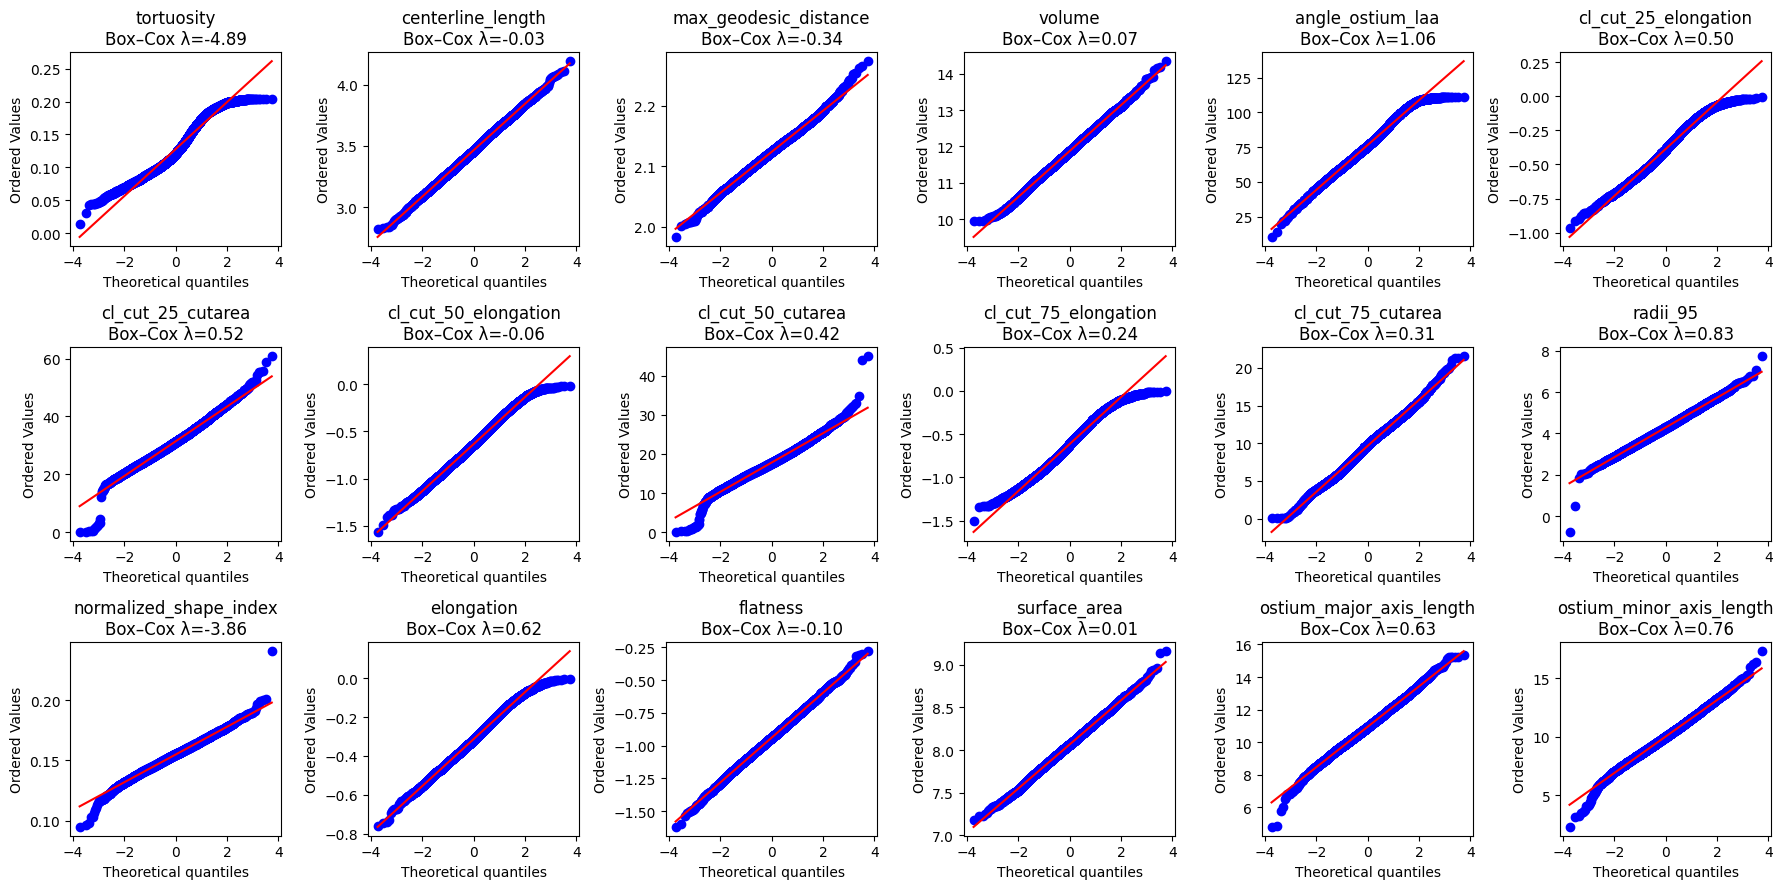

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(3, 6, figsize=(18, 9))

for i, key in enumerate(keys):
    ax = axs[i // 6, i % 6]

    # Drop NaNs
    data = df[key].dropna().values

    # Need strictly positive values for Box–Cox ⇒ shift if necessary
    shift = 0.0
    if data.size == 0:
        ax.set_title(f"{key}\n(no data)")
        continue

    min_val = data.min()
    if min_val <= 0:
        shift = -min_val + 1e-8  # tiny epsilon to make strictly > 0

    data_pos = data + shift

    # Handle possible edge case where data is (almost) constant
    try:
        data_bc, lam = stats.boxcox(data_pos)
        stats.probplot(data_bc, dist="norm", plot=ax)
        if shift != 0.0:
            ax.set_title(f"{key}\nBox–Cox λ={lam:.2f}, shift={shift:.2g}")
        else:
            ax.set_title(f"{key}\nBox–Cox λ={lam:.2f}")
    except ValueError:
        # Fallback: plot QQ of original data if Box–Cox fails
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{key}\n(Box–Cox failed)")

plt.tight_layout()
plt.show


In [120]:
#scale the data with standard scaler 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[keys] = scaler.fit_transform(df[keys])
df_scaled.head()

,filename,tortuosity,centerline_length,max_geodesic_distance,volume,angle_ostium_laa,cl_cut_25_elongation,cl_cut_25_cutarea,cl_cut_50_elongation,cl_cut_50_cutarea,cl_cut_75_elongation,cl_cut_75_cutarea,radii_95,normalized_shape_index,elongation,flatness,surface_area,ostium_major_axis_length,ostium_minor_axis_length
0,CGPS-1_0000_SERIES0014.nii.gz,-0.416702,-1.664309,-1.464416,-0.458006,1.439857,-0.656694,2.169424,1.683522,0.682007,0.494423,1.240403,-0.033730,-0.293574,-0.353913,1.963451,-0.471003,-0.888593,-0.151935
1,CGPS-1_0001_SERIES0005.nii.gz,1.240892,-0.040277,-0.404905,-1.094462,2.072447,0.077450,-1.659365,2.616632,-1.147578,0.010592,0.043584,-1.024715,-0.459568,0.476760,0.310048,-1.170625,-1.954627,-0.132176
2,CGPS-1_0003_SERIES0001.nii.gz,-0.576353,-0.644374,-0.419453,0.372783,-0.888510,0.890371,0.593051,-0.295777,0.685092,-0.207519,0.252103,0.903392,0.253656,1.057823,1.518968,0.462420,1.346154,0.791037
3,CGPS-1_0007_SERIES0007.nii.gz,1.197438,0.664058,0.271698,0.926169,0.522736,-1.585167,2.410645,-1.207480,1.074821,0.945094,-1.129201,0.766544,0.429434,0.945343,0.831803,1.018319,0.435982,-0.157252
4,CGPS-1_0008_SERIES0006.nii.gz,-0.119544,-0.049764,-0.372993,-0.418507,-0.331226,-0.064780,0.335162,0.575592,-0.652748,-1.084687,-0.492730,0.129769,-0.434370,0.078256,0.050696,-0.461611,-1.001812,1.334686


In [123]:
#get the mean value of the scaled data
mean_vector = np.mean(df_scaled[keys].values, axis=0)
mean_vector.shape

(18,)

In [124]:
x_new = mean_vector + L @ np.random.randn(len(keys))
print(x_new)

[-1.80565461 -1.33642287 -1.17721295 -1.28844126 -1.83567005  0.82522102
 -0.88776801 -1.12377741 -1.59735878 -0.73893721 -1.12173186 -0.94339565
 -1.78572386 -0.23691638  0.11541384 -1.51434899 -1.12744386 -1.02485911]


In [125]:
#scale x_new back to original scale
x_new_original = scaler.inverse_transform(x_new.reshape(1, -1))
print(x_new_original)
print(x_new*scaler.scale_ + scaler.mean_)


[[8.41287999e-01 2.85864475e+01 3.91648808e+01 3.51618343e+03
  4.05627823e+01 7.73047053e-01 1.77212443e+02 4.01142011e-01
  4.93182745e+01 4.09628926e-01 1.94189993e+01 5.33055735e+00
  1.20143440e+00 6.84095973e-01 4.20731488e-01 1.66732449e+03
  2.17243759e+01 1.38815661e+01]]
[8.41287999e-01 2.85864475e+01 3.91648808e+01 3.51618343e+03
 4.05627823e+01 7.73047053e-01 1.77212443e+02 4.01142011e-01
 4.93182745e+01 4.09628926e-01 1.94189993e+01 5.33055735e+00
 1.20143440e+00 6.84095973e-01 4.20731488e-01 1.66732449e+03
 2.17243759e+01 1.38815661e+01]


In [98]:
scaler.scale_

array([2.49392045e-01, 8.66619216e+00, 5.98725467e+00, 2.32066689e+03,
       1.25298907e+01, 1.39345743e-01, 8.88946435e+01, 1.34566428e-01,
       7.61896825e+01, 1.68089914e-01, 7.67482697e+01, 9.92111932e-01,
       3.77728646e-02, 1.05971506e-01, 6.53452499e-02, 6.71048860e+02,
       4.10219220e+00, 3.06214906e+00])

In [132]:
q_lower = norm_params['lower_quantile'][norm_params["feature"].isin(keys)].values
q_upper = norm_params['upper_quantile'][norm_params["feature"].isin(keys)].values
q_lower
q_upper

array([6.32320479e+01, 6.39447185e+01, 2.23723692e+00, 8.65383602e+00,
       5.08507704e+02, 9.51675456e-01, 4.09474242e+02, 9.18830379e-01,
       3.69386195e+02, 9.27361971e-01, 1.34707201e+04, 4.58976294e+03,
       1.37033797e+00, 3.67909120e+01, 2.46145024e+01, 9.47427269e-01,
       5.95282615e-01, 8.90631679e+01])

In [ ]:
np.savez_compressed("/data/Data/laa_measures/cond_distr_std_mean_scaled.npz",
                    mean=scaler.mean_,
                    scale=scaler.scale_,
                    cov_matrix=cov_matrix,
                    L=L,
                    q_lower = ,
                    q_upper = )

In [106]:
keys

['tortuosity',
 'centerline_length',
 'max_geodesic_distance',
 'volume',
 'angle_ostium_laa',
 'cl_cut_25_elongation',
 'cl_cut_25_cutarea',
 'cl_cut_50_elongation',
 'cl_cut_50_cutarea',
 'cl_cut_75_elongation',
 'cl_cut_75_cutarea',
 'radii_95',
 'normalized_shape_index',
 'elongation',
 'flatness',
 'surface_area',
 'ostium_major_axis_length',
 'ostium_minor_axis_length']

In [128]:
df["tortuosity"].quantile(0.01)

1.0779340303535732

In [129]:
norm_params['lower_quantile'][norm_params["feature"]=="tortuosity"].values

array([1.07793487])

In [130]:
q_lower

array([3.41305048e+01, 2.40946053e+01, 1.07793487e+00, 4.08437690e+00,
       9.71003341e+01, 3.89784905e-01, 4.40535571e+01, 3.12150484e-01,
       8.02315757e+00, 2.43737533e-01, 2.61780970e+03, 1.46468781e+03,
       1.19124763e+00, 1.72382504e+01, 1.01703200e+01, 4.80577475e-01,
       2.83240154e-01, 3.42273354e+01])

In [147]:
laa_measures_list = csv2list(input_path, exclude_list)
df = pd.DataFrame(laa_measures_list)

# Identify numeric columns. (We assume both laa_measuress have the same keys.)
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Make copies for the normalized versions
df_norm = df.copy()
#if any value in a row is nan, drop the row
df_norm = df_norm.dropna()

norm_params = []

# For each numeric column, compute the union quantiles and normalize
for col in tqdm(numeric_cols):
    if col in keys:
        q_001 = df[col].quantile(0.01)
        q_099 = df[col].quantile(0.99)
        q_0025 = df[col].quantile(0.025)
        q_0975 = df[col].quantile(0.975)
        mean = df[col].mean()
        std = df[col].std()
        norm_params.append({'feature': col, 'Q_0.01': q_001, 'Q_0.99': q_099, 'Q_0.025': q_0025, 'Q_0.975': q_0975, 'mean': mean, 'std': std})

No label files for the following scans: ['CGPS-1_0002_SERIES0017']


100%|██████████| 42/42 [00:00<00:00, 2175.79it/s]


In [146]:
norm_params_df = pd.DataFrame(norm_params)
norm_params_df.to_csv("/storage/code/VQ_diffusion/help_folder/statistics/quantile_std_mean_params.csv", index=False)

In [136]:
cov_matrix

array([[ 1.0001318 ,  0.54925399,  0.22100148, -0.00794326,  0.2119294 ,
         0.00789816, -0.18870582,  0.20511797, -0.25754963,  0.29423695,
        -0.29279231, -0.10349323,  0.1462649 , -0.01337692,  0.07097091,
         0.02663682, -0.04091705, -0.01005465],
       [ 0.54925399,  1.0001318 ,  0.76768728,  0.44224826,  0.18192197,
         0.01219484,  0.01245745,  0.05788534, -0.14348939,  0.18839767,
        -0.27360993,  0.192688  ,  0.32913921, -0.37765661, -0.3679732 ,
         0.50117939,  0.28129626,  0.20710281],
       [ 0.22100148,  0.76768728,  1.0001318 ,  0.7286371 ,  0.00641329,
        -0.02573931,  0.33863097, -0.03995604,  0.19941238,  0.04576269,
         0.06170008,  0.47297447,  0.28562024, -0.24634017, -0.33051844,
         0.76311634,  0.51813914,  0.39875954],
       [-0.00794326,  0.44224826,  0.7286371 ,  1.0001318 ,  0.14857674,
        -0.02308221,  0.72831993, -0.13205145,  0.57891871, -0.12034321,
         0.38615548,  0.76331568,  0.10799384,  0.062